In [1]:
import json
import gzip
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib as mpl
from itertools import product
import json
import os
import xtrack as xt

In [2]:
import sys
helper_dir = Path("/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/HelperFunctions")
sys.path.insert(0, str(helper_dir)) 

In [3]:
import midpoints_analysis as mpa

# Pre

In [4]:
path_MD_data = Path('/Users/lisepauwels/sps_simulations/MD_data/20250616/')
path_study_results = Path("/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/IntensityScan2/study_results")
name_files = [p.name for p in path_study_results.iterdir()]

In [5]:
def get_measurements_combinations(deltas_plus, deltas_min):
    return list(product(deltas_plus, deltas_min))

def df_to_delta(df):
    slip_factor = 0.0017935055033301713
    f = 200_000_000
    return 1/slip_factor * df/f

def interpolate_50_val(xvals, yvals):
    if np.any(yvals <= 0.5):  # ensure the curve actually crosses 0.5
        idx_above = np.where(yvals > 0.5)[0][-1]   # last index above 0.5
        idx_below = idx_above + 1                  # first index below 0.5

        # Linear interpolation for more accuracy
        x50 = np.interp(0.5, [yvals[idx_above], yvals[idx_below]],
                            [xvals[idx_above], xvals[idx_below]])
        return x50
    else:
        print("Warning: The curve does not cross 0.5")
        return None
    
def get_acceptance_and_center(delta_plus, delta_minus):
    if delta_plus is None or delta_minus is None:
        return None
    center = 0.5 * (delta_plus + delta_minus)
    acceptance = delta_plus - delta_minus
    return center, acceptance

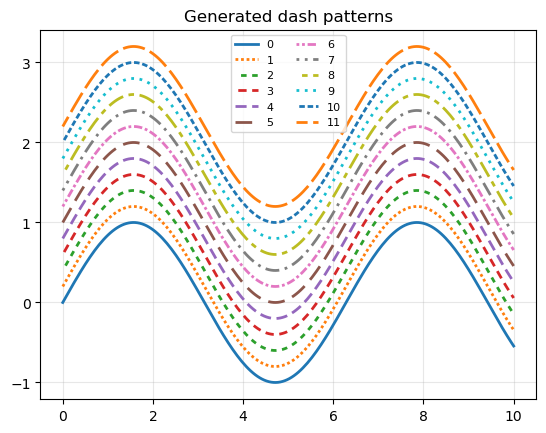

In [6]:
def generate_distinct_dashes(
    n: int,
    *,
    min_on: float = 1.0,
    max_on: float = 10.0,
    min_off: float = 1.0,
    max_off: float = 10.0,
    include_solid: bool = True,
):
    """
    Generate `n` visually distinct linestyles for Matplotlib.

    Returns a list of linestyles usable as `linestyle=...` in ax.plot:
      - "-" for solid (optional)
      - dash tuples of the form (offset, (on, off, on, off, ...))

    The patterns are built from a small set of base "motifs" and scaled/offset
    so they remain distinguishable without becoming too chaotic.
    """
    if n <= 0:
        return []

    styles = []
    if include_solid:
        styles.append("-")
        if n == 1:
            return styles
        n_remaining = n - 1
    else:
        n_remaining = n

    # Base motifs: dashed, dotted, dash-dot, long-short, etc.
    motifs = [
        (1, 1),           # dotted
        (2, 2),           # short dashed
        (3, 2),           # medium dash
        (4, 2),           # longer dash
        (6, 3),           # long dash
        (3, 1, 1, 1),     # dash-dot (tight)
        (5, 2, 1, 2),     # dash-dot (looser)
        (6, 2, 2, 2),     # long-short
        (1, 2),           # sparse dots
        (2, 1),           # dense dashes
        (8, 2),           # very long dash
        (2, 2, 6, 2),     # two-dash motif
    ]

    # Choose scale factors so patterns spread out but stay readable
    # Use a quasi-log spacing (helps keep early patterns distinct).
    scales = np.geomspace(1.0, 2.5, num=max(1, int(np.ceil(n_remaining / len(motifs)))))
    offsets = np.linspace(0.0, 6.0, num=max(2, int(np.ceil(n_remaining / 3))))  # small phase offsets

    def clamp(v, lo, hi):
        return float(np.clip(v, lo, hi))

    k = 0
    for s in scales:
        for motif in motifs:
            if k >= n_remaining:
                break

            # Scale motif and clamp to keep it within sensible dash lengths
            scaled = []
            for i, v in enumerate(motif):
                if i % 2 == 0:  # "on"
                    scaled.append(clamp(v * s, min_on, max_on))
                else:           # "off"
                    scaled.append(clamp(v * s, min_off, max_off))

            offset = float(offsets[k % len(offsets)])
            styles.append((offset, tuple(scaled)))
            k += 1

        if k >= n_remaining:
            break

    return styles


# ---------------- Example usage ----------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    x = np.linspace(0, 10, 200)
    styles = generate_distinct_dashes(12, include_solid=True)

    fig, ax = plt.subplots()
    for i, ls in enumerate(styles):
        ax.plot(x, np.sin(x) + i * 0.2, linestyle=ls, linewidth=2, label=f"{i}")
    ax.set_title("Generated dash patterns")
    ax.legend(ncol=2, fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()


In [7]:
sweep_per_turn = 1.0
data_simulations = {'linear' : {}, 'errors': {}}
for name_file in name_files:
    with gzip.open(path_study_results / name_file, "rt") as f:
        study_results = json.load(f)

    line_type = name_file.split("_")[1]
    chroma = float(name_file.split("_")[2].split(".json")[0])
    print(line_type, chroma)
    if chroma not in data_simulations[line_type]:
        data_simulations[line_type][chroma] = {}
    
    for plane in list(study_results.keys()):
        assert abs(study_results[plane]['sweep_per_turn']) == sweep_per_turn
        turns, counts = np.unique(study_results[plane]['at_turn'], return_counts=True)
        data_simulations[line_type][chroma][plane] = {'turns' : turns, 'counts' : counts}

errors 0.1
linear -0.2
errors -0.1
linear 0.3
errors -1.5
errors 1.5
linear 1.1
errors -0.7
linear 0.8
errors 0.7
linear -0.4
errors 1.3
linear -1.0
linear 0.5
linear -0.9
errors -1.3
linear -0.3
errors 0.0
errors -1.4
linear 0.2
errors 1.4
errors -0.6
linear 1.0
linear -0.5
linear 0.9
errors 0.6
linear -1.1
errors 1.2
errors -1.2
linear -0.8
linear 0.4
linear 1.5
errors -0.3
errors 0.3
linear -1.4
linear 0.1
errors 0.5
linear -0.6
linear 1.3
errors -0.5
linear 0.7
errors 0.8
errors -1.1
errors 1.1
errors -0.8
linear -1.2
errors -0.2
linear 1.4
linear -0.1
errors 0.2
linear -1.5
linear 0.0
linear -0.7
errors 0.4
errors -0.4
linear 1.2
errors -1.0
linear 0.6
errors 0.9
linear -1.3
errors -0.9
errors 1.0


In [8]:
normalised_intensity = {}
num_particles = 2000 * 500
for line_type in ['linear', 'errors']:
    normalised_intensity[line_type] = {}
    for chroma in sorted(data_simulations[line_type].keys()):
        normalised_intensity[line_type][chroma] = {}
        for plane in ['DPpos', 'DPneg']:
            turns = data_simulations[line_type][chroma][plane]['turns']
            counts = data_simulations[line_type][chroma][plane]['counts']

            turns = np.concatenate(([0], turns))
            counts = np.concatenate(([0], counts))

            deltas = df_to_delta(turns * sweep_per_turn)
            if plane == 'DPneg':
                deltas = -deltas
            
            normalised_intensity[line_type][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / num_particles}

# Intensity plots

In [16]:
def chroma_to_color(cmap, norm, chroma):
    return cmap(norm(chroma))

def plot_intensity_drop(normalised_intensity, planes = ['DPpos', 'DPneg'], line_types=None, chromas=None, line_styles=None, cmap=None, savefig=None, deltaq=False, ax=None, symmetrize=False, subtract=False, labels = None, fig=None, func_xscale=None, colorbar=True, sign=1):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    else:
        assert fig is not None

    if labels is None:
        labels = [r"$\delta$", 'Normalised Intensity Loss']
    
    if line_types is None:
        line_types = list(normalised_intensity.keys())
    if chromas is None:
        chromas = list(normalised_intensity[line_types[0]])

    if line_styles is None:
        line_styles = {}
        if len(line_types) <= 4:
            ls_basic = ['-', '--', '-.', ':']
            for i, lt in enumerate(line_types):
                line_styles[lt] = ls_basic[i]
        else:
            styles = generate_distinct_dashes(len(line_types), include_solid=True)
            for i, lt in enumerate(line_types):
                line_styles[lt] = styles[i]
    
    if cmap is None:
        cmap = colormaps['plasma']
    
    all_chromas = sorted({ch for lt in normalised_intensity for ch in normalised_intensity[lt].keys()})
    vmin, vmax = min(all_chromas), max(all_chromas)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    for lt in line_types:
        for c in chromas:
            for plane in planes:
                if symmetrize:
                    foo = abs
                else:
                    foo = lambda _: _
                if deltaq:
                    tmp = (foo(normalised_intensity[lt][c][plane]['deltas'] * c * 20.13) + 20.13*1) * 1
                else:
                    tmp = foo(normalised_intensity[lt][c][plane]['deltas'])
                
                if subtract:
                    tmp = tmp[:1200]
                    intensity_vals = (normalised_intensity[lt][c][plane]['values'][0:1200] - normalised_intensity[lt][0][plane]['values'][0:1200])/(normalised_intensity[lt][0][plane]['values'][0:1200])
                else:
                    intensity_vals = normalised_intensity[lt][c][plane]['values']
                
                if func_xscale is not None:
                    tmp2 = tmp
                    tmp = func_xscale(tmp2)#*20 +20.13

                # xxx = []
                # for i in tmp:
                #     if i * c > 0:
                #         xxx.append(1)
                #     else:
                #         xxx.append(0)
                ax.plot(
                    sign * tmp,
                    intensity_vals,
                    color=chroma_to_color(cmap, norm, c),
                    linestyle=line_styles[lt],
                )
                # ax.plot(
                #     # tmp,
                #     # normalised_intensity[lt][c][plane]['values'],
                #     tmp[:1200],
                #     (normalised_intensity[lt][c][plane]['values'][0:1200] - normalised_intensity[lt][0][plane]['values'][0:1200])/(normalised_intensity[lt][0][plane]['values'][0:1200]),
                #     color=chroma_to_color(cmap, norm, c),
                #     linestyle=line_styles[lt],
                # )
    
    line_handles = [
        Line2D([0], [0], color='black', linestyle=line_styles[lt], linewidth=2, label=lt)
        for lt in line_styles
    ]
    if colorbar:
        # legend_model = ax.legend(handles=line_handles, title="Model", loc="upper left", frameon=True)
        # ax.add_artist(legend_model)

        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])  # required by older mpl for colorbar
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label(r"Normalised Chromaticity  $\xi_x$", fontsize=12)

    ax.set_xlabel(labels[0], fontsize=12)
    ax.set_ylabel(labels[1], fontsize=12)
    ax.grid()
    fig.tight_layout()

    if savefig is not None:
        figures_path = os.path.join(os.getcwd(), "Figures")

        if os.path.isdir(figures_path):
            plt.savefig(os.path.join(figures_path, savefig), dpi=300)
        else:
            plt.savefig(savefig, dpi=300)
    
    return fig, ax

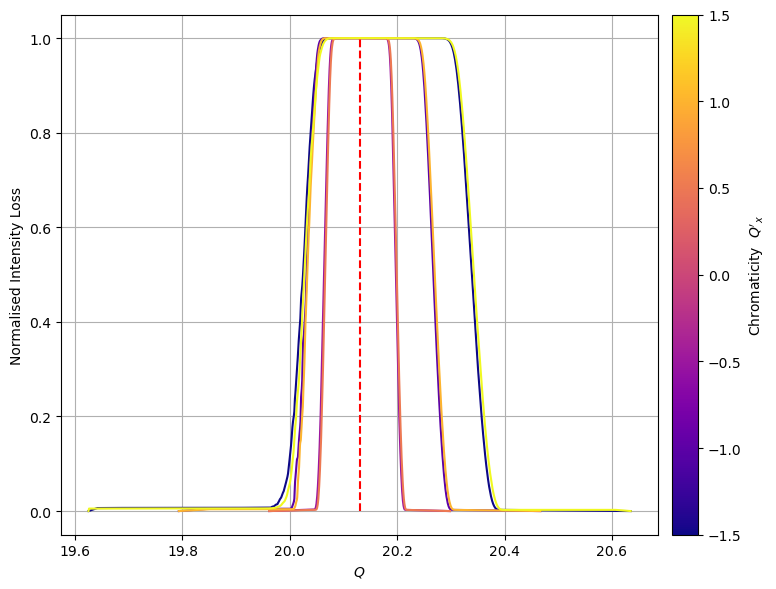

In [10]:
fig, ax = plot_intensity_drop(normalised_intensity, chromas=[-1.5, -1.0, -0.5, 0.5, 1.0, 1.5], line_types=['linear'], deltaq=True, symmetrize=False, labels = [r"$Q$", 'Normalised Intensity Loss'])
ax.vlines(20.13, 0, 1.0, ls = '--', color = 'r')


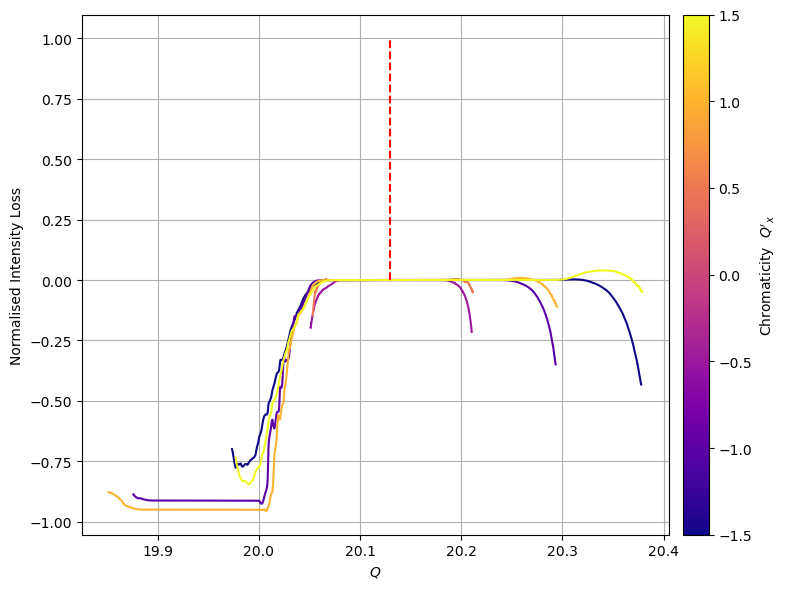

In [11]:
fig, ax = plot_intensity_drop(normalised_intensity, chromas=[-1.5, -1.0, -0.5, 0.5, 1.0, 1.5], line_types=['linear'], deltaq=True, symmetrize=False, labels = [r"$Q$", 'Normalised Intensity Loss'], subtract=True)
ax.vlines(20.13, 0, 1.0, ls = '--', color = 'r')


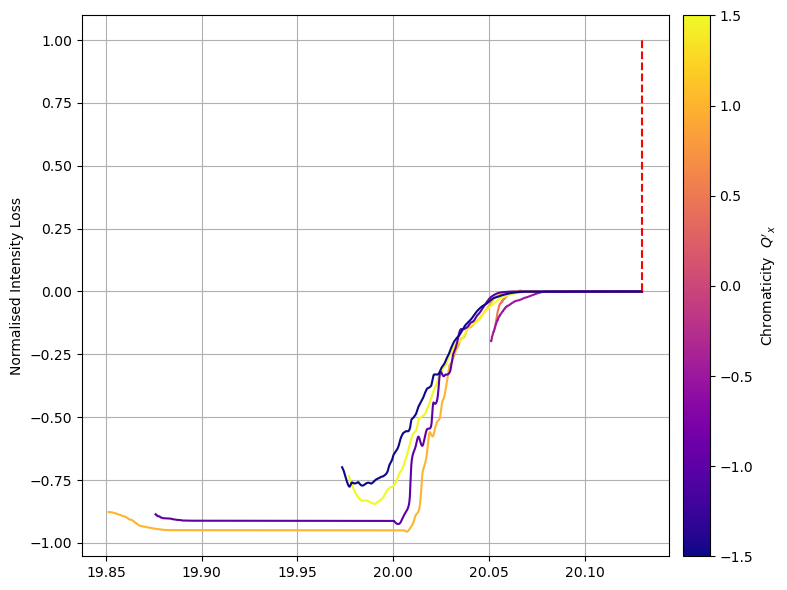

In [12]:
chromas = [-1.5, -1.0, -0.5, 0.5, 1.0, 1.5]
chromas_pos = np.array([0.5, 1.0, 1.5])
chromas_neg = -chromas_pos
fig, ax = plot_intensity_drop(normalised_intensity, planes = ['DPneg'], chromas=chromas_pos, line_types=['linear'], deltaq=True, symmetrize=False, labels = [r"$ Q$", 'Normalised Intensity Loss'], subtract=True)
plot_intensity_drop(normalised_intensity, planes = ['DPpos'], chromas=chromas_neg, line_types=['linear'], deltaq=True, symmetrize=False, labels = ["", 'Normalised Intensity Loss'], subtract=True, ax=ax, fig=fig, colorbar=False)
ax.grid()
# plot_intensity_drop(normalised_intensity, planes = ['DPpos'], chromas=chromas_pos, line_types=['linear'], deltaq=False, symmetrize=True, labels = ["", 'Normalised Intensity Loss'], subtract=True, ax=ax, fig=fig, colorbar=False, func_xscale=disp_shift)
# plot_intensity_drop(normalised_intensity, planes = ['DPneg'], chromas=chromas_neg, line_types=['linear'], deltaq=False, symmetrize=True, labels = ["", 'Normalised Intensity Loss'], subtract=True, ax=ax, fig=fig, colorbar=False, func_xscale=disp_shift) #func_xscale=disp_shift

ax.vlines(20.13, 0, 1.0, ls = '--', color = 'r')

In [13]:
fig, ax = plot_intensity_drop(normalised_intensity, planes = ['DPneg'], chromas=chromas_neg, line_types=['linear'], deltaq=False, symmetrize=True, labels = ["", 'Normalised Intensity Loss'], subtract=True, colorbar=False, func_xscale=dx_shift) #func_xscale=disp_shift
plot_intensity_drop(normalised_intensity, planes = ['DPpos'], chromas=chromas_pos, line_types=['linear'], deltaq=False, symmetrize=True, labels = ["", 'Normalised Intensity Loss'], subtract=True, ax=ax, fig=fig, colorbar=False, func_xscale=dx_shift) #func_xscale=disp_shift
ax.grid()

NameError: name 'dx_shift' is not defined

In [14]:
fig, ax = plot_intensity_drop(normalised_intensity, planes = ['DPneg'], chromas=chromas_neg, line_types=['linear'], deltaq=False, symmetrize=True, labels = ["", 'Normalised Intensity Loss'], subtract=True, colorbar=False, func_xscale=dx_shift) #func_xscale=disp_shift
plot_intensity_drop(normalised_intensity, planes = ['DPpos'], chromas=chromas_pos, line_types=['linear'], deltaq=False, symmetrize=True, labels = ["", 'Normalised Intensity Loss'], subtract=True, ax=ax, fig=fig, colorbar=False, func_xscale=dx_shift) #func_xscale=disp_shift
ax.grid()

NameError: name 'dx_shift' is not defined

# Better plots

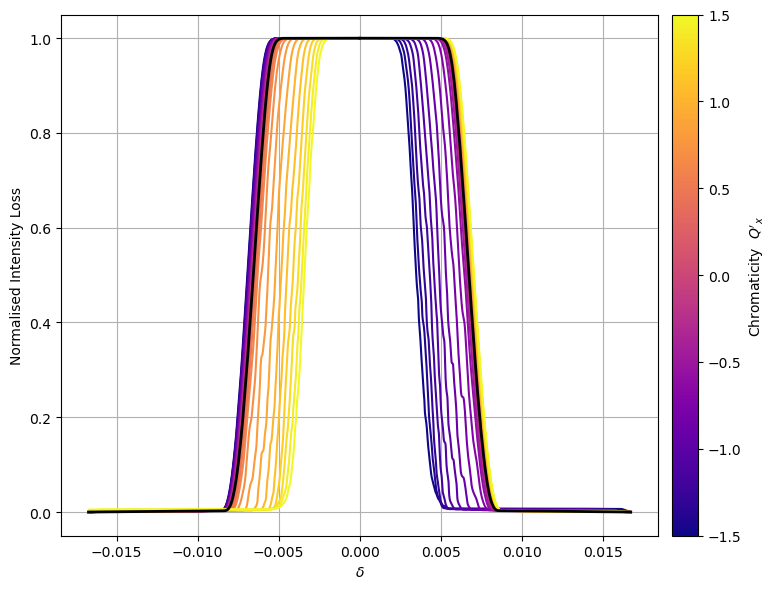

In [15]:
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=False, symmetrize=False)
ax.plot(normalised_intensity['linear'][0.0]['DPpos']['deltas'], normalised_intensity['linear'][0.0]['DPpos']['values'], color='k', lw = 2)
ax.plot(normalised_intensity['linear'][0.0]['DPneg']['deltas'], normalised_intensity['linear'][0.0]['DPneg']['values'], color='k', lw = 2)

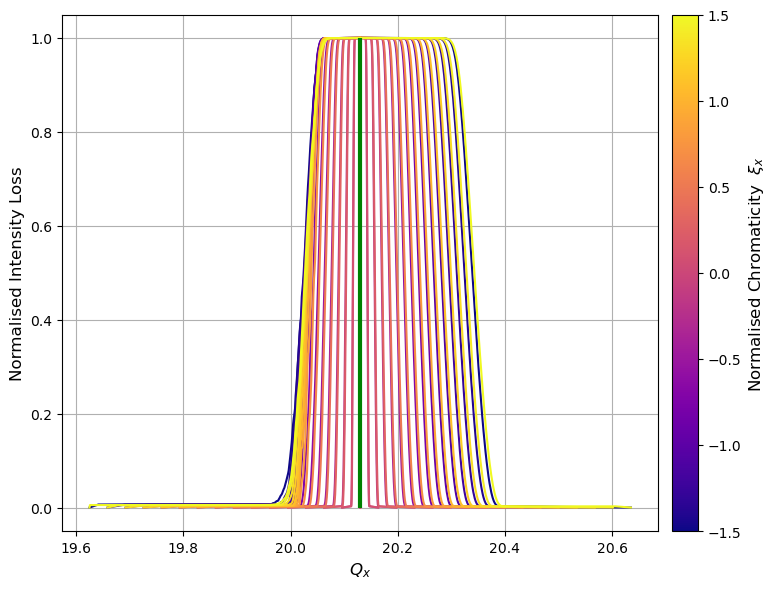

In [17]:
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=True, symmetrize=False, labels = ["$Q_x$", "Normalised Intensity Loss"])
ax.vlines(20.13, 0, 1.0, ls = '-', lw = 3, color = 'g')
# ax.vlines()

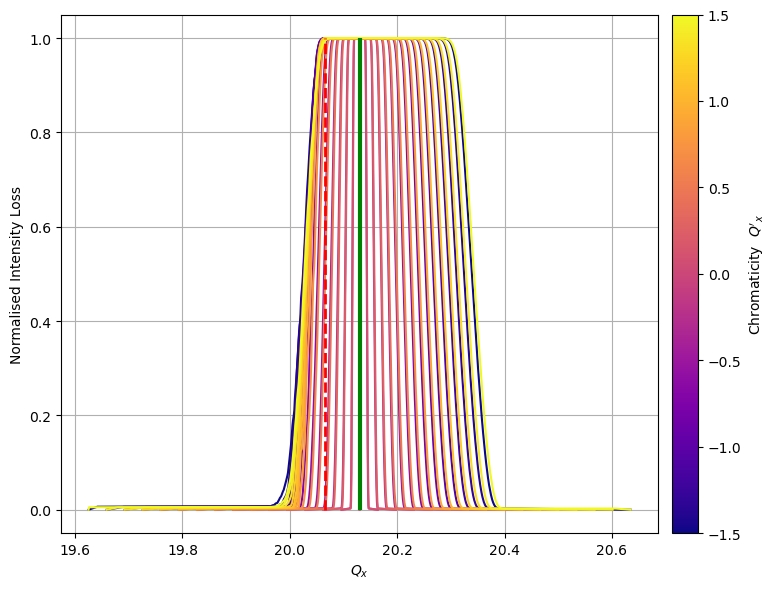

In [70]:
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=True, symmetrize=False, labels = ["$Q_x$", "Normalised Intensity Loss"])
ax.vlines(20.13, 0, 1.0, ls = '-', lw = 3, color = 'g')
ax.vlines(20.065, 0, 1.0, ls = '--', lw = 2, color = 'r')

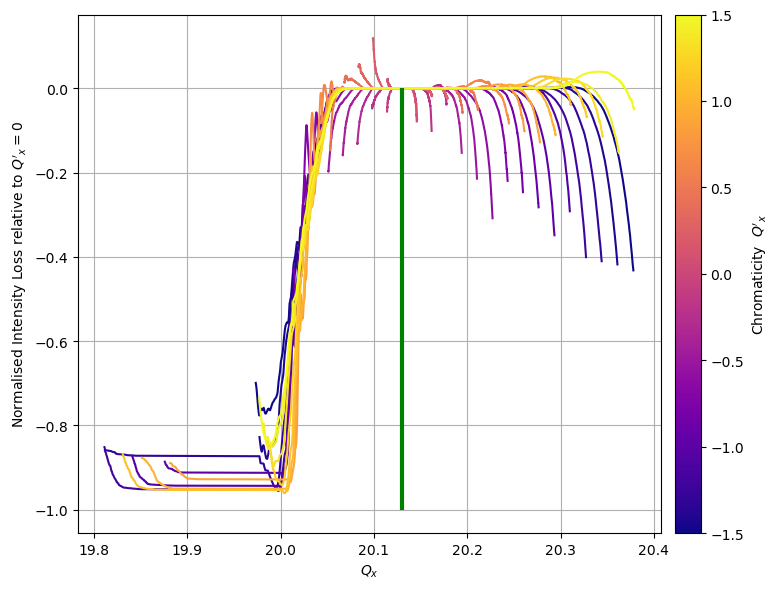

In [ ]:
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=True, symmetrize=False, subtract=True, labels = ["$Q_x$", "Normalised Intensity Loss relative to $Q'_x = 0$"])
ax.vlines(20.13, -1.0, 0., ls = '-', lw = 3, color = 'g')

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_61625/447078363.py:3: SyntaxWarning: invalid escape sequence '\d'
  fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"])
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_61625/447078363.py:4: SyntaxWarning: invalid escape sequence '\d'
  plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)


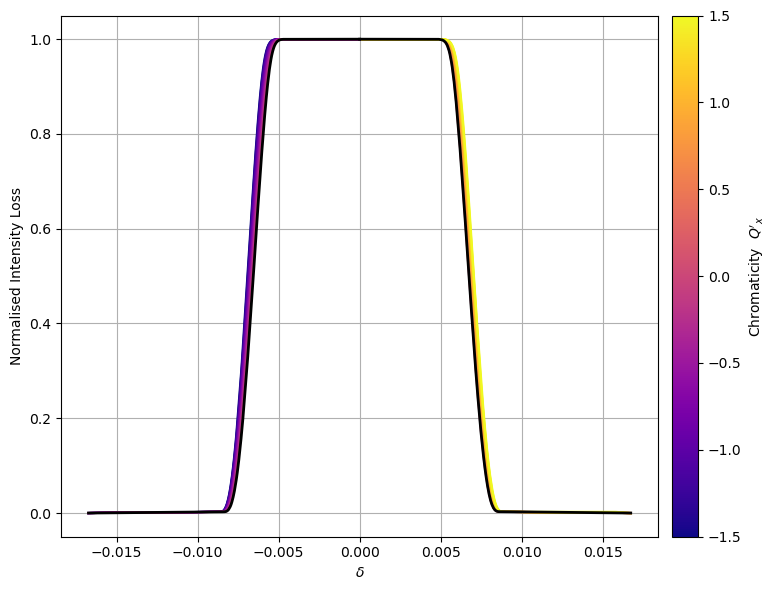

In [ ]:
chromas = np.array(list(normalised_intensity['linear'].keys()))
mask = chromas >= 0 
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"])
plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)
ax.grid()
ax.plot(normalised_intensity['linear'][0.0]['DPpos']['deltas'], normalised_intensity['linear'][0.0]['DPpos']['values'], color='k', lw = 2)
ax.plot(normalised_intensity['linear'][0.0]['DPneg']['deltas'], normalised_intensity['linear'][0.0]['DPneg']['values'], color='k', lw = 2)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/428187490.py:1: SyntaxWarning: invalid escape sequence '\d'
  fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/428187490.py:2: SyntaxWarning: invalid escape sequence '\d'
  plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)


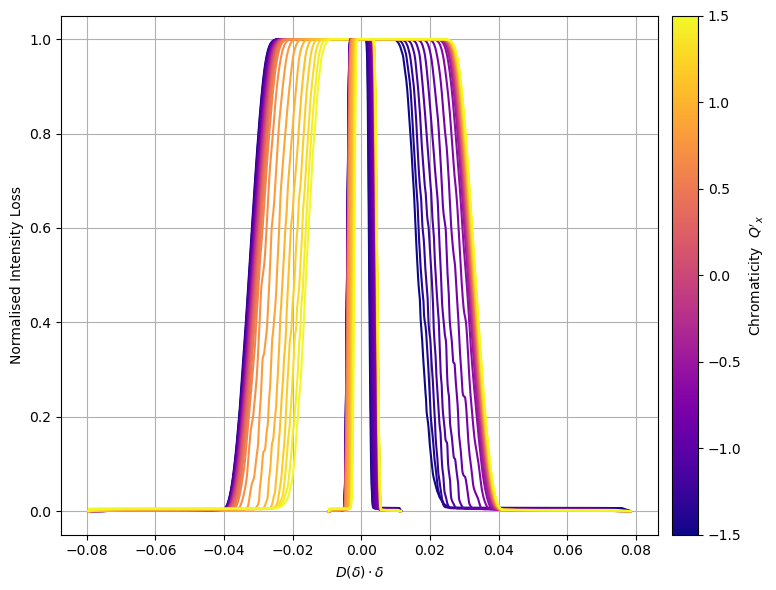

In [56]:
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
plot_intensity_drop(normalised_intensity, line_types=['linear'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)
ax.grid()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/3277743136.py:3: SyntaxWarning: invalid escape sequence '\d'
  fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/3277743136.py:4: SyntaxWarning: invalid escape sequence '\d'
  plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)


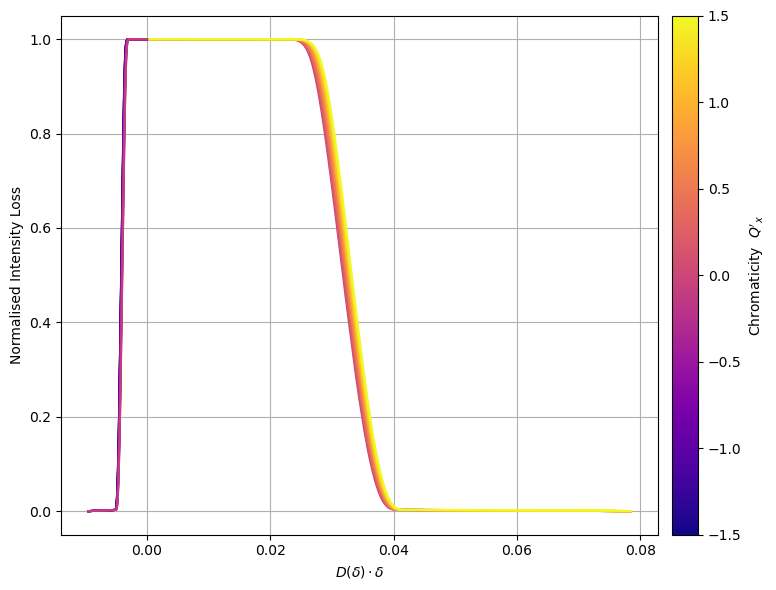

In [50]:
chromas = np.array(list(normalised_intensity['linear'].keys()))
mask = chromas >= 0 
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)
ax.grid()
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPpos']['deltas']), normalised_intensity['linear'][0.0]['DPpos']['values'], color='k', lw = 2)
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPneg']['deltas']), normalised_intensity['linear'][0.0]['DPneg']['values'], color='k', lw = 2)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/2838248023.py:1: SyntaxWarning: invalid escape sequence '\d'
  fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = [-0.3, 0.0], planes = ['DPpos', 'DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])


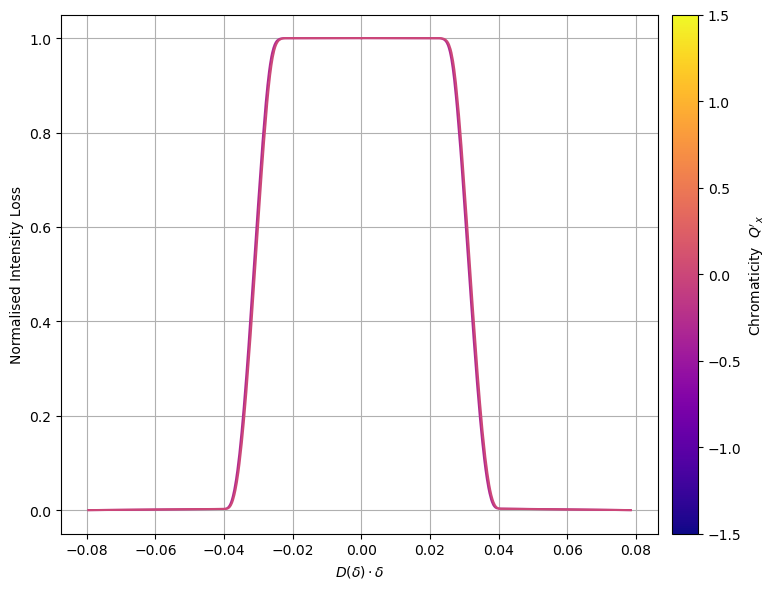

In [59]:
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = [-0.3, 0.0], planes = ['DPpos', 'DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/2536077480.py:3: SyntaxWarning: invalid escape sequence '\d'
  fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = [0.0], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/2536077480.py:4: SyntaxWarning: invalid escape sequence '\d'
  plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = [0.0], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)


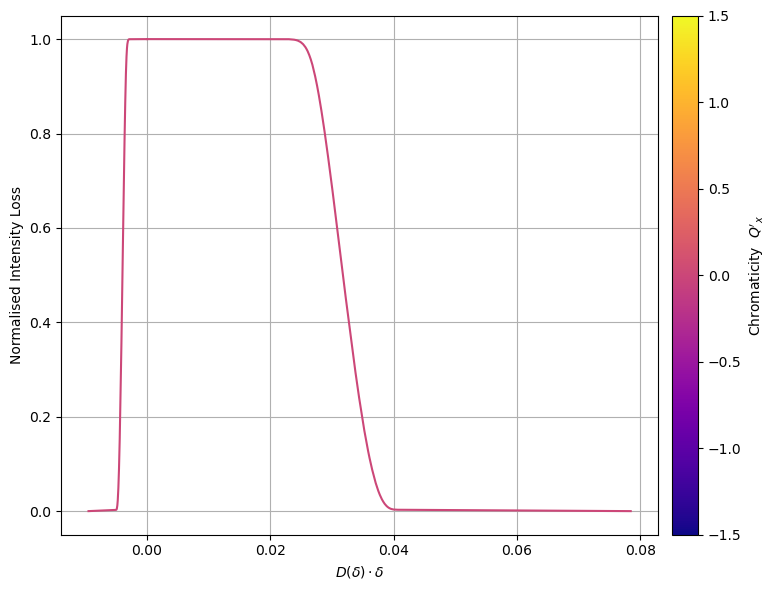

In [53]:
chromas = np.array(list(normalised_intensity['linear'].keys()))
mask = chromas >= 0 
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = [0.0], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = [0.0], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False)
ax.grid()
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPpos']['deltas']), normalised_intensity['linear'][0.0]['DPpos']['values'], color='k', lw = 2)
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPneg']['deltas']), normalised_intensity['linear'][0.0]['DPneg']['values'], color='k', lw = 2)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/1342440972.py:3: SyntaxWarning: invalid escape sequence '\d'
  fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/1342440972.py:4: SyntaxWarning: invalid escape sequence '\d'
  plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False, sign=-1)


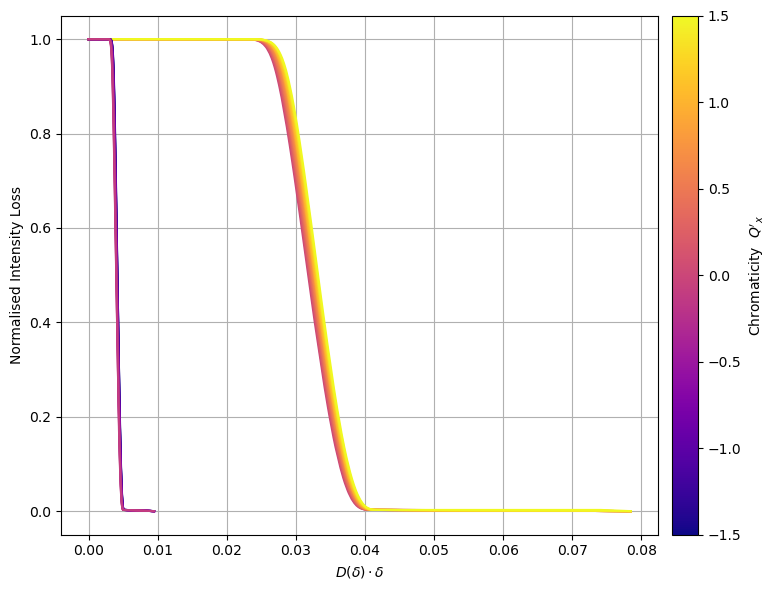

In [48]:
chromas = np.array(list(normalised_intensity['linear'].keys()))
mask = chromas >= 0 
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=disp_shift2, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"])
plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=disp_shift, labels = ["$D(\delta) \cdot \delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False, sign=-1)
ax.grid()
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPpos']['deltas']), normalised_intensity['linear'][0.0]['DPpos']['values'], color='k', lw = 2)
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPneg']['deltas']), normalised_intensity['linear'][0.0]['DPneg']['values'], color='k', lw = 2)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/2418101190.py:3: SyntaxWarning: invalid escape sequence '\d'
  fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"])
/var/folders/b5/swvf1qzj6l36gcd1zzs4_g8h0000gn/T/ipykernel_69535/2418101190.py:4: SyntaxWarning: invalid escape sequence '\d'
  plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False, sign=-1)


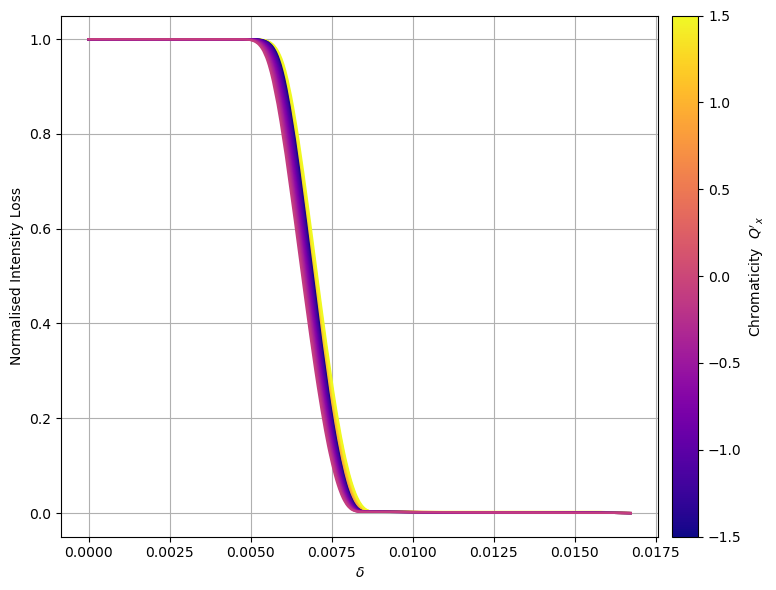

In [34]:
chromas = np.array(list(normalised_intensity['linear'].keys()))
mask = chromas >= 0 
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[mask], planes = ['DPpos'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"])
plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = chromas[~mask], planes = ['DPneg'], deltaq=False, symmetrize=False, func_xscale=None, labels = ["$\delta$", "Normalised Intensity Loss"], fig=fig, ax=ax, colorbar=False, sign=-1)
ax.grid()
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPpos']['deltas']), normalised_intensity['linear'][0.0]['DPpos']['values'], color='k', lw = 2)
# ax.plot(disp_shift(normalised_intensity['linear'][0.0]['DPneg']['deltas']), normalised_intensity['linear'][0.0]['DPneg']['values'], color='k', lw = 2)

In [16]:
chromas = np.array(list(normalised_intensity['linear'].keys()))
mask = chromas >= 0

# Disp

In [17]:
midpoints90 = mpa.get_midpoints(normalised_intensity, percentile=0.9)
midpoints50 = mpa.get_midpoints(normalised_intensity, percentile=0.5)
midpoints10 = mpa.get_midpoints(normalised_intensity, percentile=0.1)

In [18]:
midpoints50

{'linear': {-1.5: {'DPpos': np.float64(0.0034959468974909186),
   'DPneg': np.float64(-0.006924985720388709)},
  -1.4: {'DPpos': np.float64(0.0036966711212703014),
   'DPneg': np.float64(-0.006905470865299047)},
  -1.3: {'DPpos': np.float64(0.003981030438291094),
   'DPneg': np.float64(-0.006888743846650765)},
  -1.2: {'DPpos': np.float64(0.004335085666346394),
   'DPneg': np.float64(-0.006872016828002484)},
  -1.1: {'DPpos': np.float64(0.004594354455394764),
   'DPneg': np.float64(-0.006852501972912821)},
  -1.0: {'DPpos': np.float64(0.004920531319036261),
   'DPneg': np.float64(-0.006824623608499018)},
  -0.9: {'DPpos': np.float64(0.005330343275919168),
   'DPneg': np.float64(-0.006802320916967975)},
  -0.8: {'DPpos': np.float64(0.005829365998926244),
   'DPneg': np.float64(-0.006782806061878313)},
  -0.7: {'DPpos': np.float64(0.006172269881216023),
   'DPneg': np.float64(-0.006760503370347271)},
  -0.6: {'DPpos': np.float64(0.006470568380443718),
   'DPneg': np.float64(-0.0067326250

In [19]:
def delta_to_qx(delta, chroma):
    return delta * chroma * 20.13

delta_to_qx(midpoints50['linear'][1.0]['DPpos'], 1.0)

np.float64(0.14007339232220453)

In [20]:
def get_subtracted_midpoint(midpoint_dict, lt, chroma, plane, ref_chroma=0.0):
    dp_val = midpoint_dict[lt][chroma][plane]
    ref_val = midpoint_dict[lt][ref_chroma][plane]
    return (dp_val - ref_val)/ref_val

In [21]:
(midpoints50['linear'][1.5]['DPneg']- midpoints50['linear'][0.0]['DPneg'])/midpoints50['linear'][0.0]['DPneg']

np.float64(-0.48108797280068)

In [22]:
delta_to_qx(midpoints90['linear'][-1.5]['DPneg'], -1.5)

np.float64(0.1840146848655884)

In [23]:
qxs

NameError: name 'qxs' is not defined

In [24]:
qxs = {90: {}, 50 : {}, 10: {}}
vals = {90: {}, 50 : {}, 10: {}}
for chroma in sorted(list(data_simulations['linear'].keys())):
    print(chroma)
    qxs[90][chroma] = {}
    qxs[50][chroma] = {}
    qxs[10][chroma] = {}
    vals[90][chroma] = {}
    vals[50][chroma] = {}
    vals[10][chroma] = {}
    for plane in ['DPpos', 'DPneg']:
        print(plane)
        qxs[90][chroma][plane] = delta_to_qx(midpoints90['linear'][chroma][plane], chroma)
        qxs[50][chroma][plane] = delta_to_qx(midpoints50['linear'][chroma][plane], chroma)
        qxs[10][chroma][plane] = delta_to_qx(midpoints10['linear'][chroma][plane], chroma)

        vals[90][chroma][plane] = get_subtracted_midpoint(midpoints90, 'linear', chroma, plane)
        vals[50][chroma][plane] = get_subtracted_midpoint(midpoints50, 'linear', chroma, plane)
        vals[10][chroma][plane] = get_subtracted_midpoint(midpoints10, 'linear', chroma, plane)

-1.5
DPpos
DPneg
-1.4
DPpos
DPneg
-1.3
DPpos
DPneg
-1.2
DPpos
DPneg
-1.1
DPpos
DPneg
-1.0
DPpos
DPneg
-0.9
DPpos
DPneg
-0.8
DPpos
DPneg
-0.7
DPpos
DPneg
-0.6
DPpos
DPneg
-0.5
DPpos
DPneg
-0.4
DPpos
DPneg
-0.3
DPpos
DPneg
-0.2
DPpos
DPneg
-0.1
DPpos
DPneg
0.0
DPpos
DPneg
0.1
DPpos
DPneg
0.2
DPpos
DPneg
0.3
DPpos
DPneg
0.4
DPpos
DPneg
0.5
DPpos
DPneg
0.6
DPpos
DPneg
0.7
DPpos
DPneg
0.8
DPpos
DPneg
0.9
DPpos
DPneg
1.0
DPpos
DPneg
1.1
DPpos
DPneg
1.2
DPpos
DPneg
1.3
DPpos
DPneg
1.4
DPpos
DPneg
1.5
DPpos
DPneg


In [ ]:
def generate_delta_sampling(delta_min, delta_max, step=None, num_points=None):
    if step is None and num_points is None:
        raise ValueError("Either 'step' or 'num_points' must be provided.")
    if step is None:
        step = (delta_max - delta_min) / num_points

    i_min = int(np.ceil(delta_min / step))
    i_max = int(np.floor(delta_max / step))

    arr = step * np.arange(i_min, i_max + 1)
    return arr

def twiss_scan(line, delta_min, delta_max, step=None, num_points=None):
    delta_values = generate_delta_sampling(delta_min, delta_max, step, num_points)
    
    idx_zero = np.where(delta_values == 0)[0][0]
    tw0 = line.twiss4d(delta0=0.0)
    twisses = []
    # twiss_pos.append(tw0)
    # twiss_neg.append(tw0)

    for delta in delta_values[:idx_zero][::-1]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co) if len(twisses)>0 else tw0)
        if delta == 0.0:
            twiss0 = twisses[-1]
    twisses = twisses[::-1]
    twisses.append(tw0)
    for delta in delta_values[idx_zero + 1:]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co))
    return delta_values, twisses, tw0

line2 = xt.load('../../injection_lines/sps_q20_inj.json')
c = 0.0
qx = 20.13
qy = 10.18
opt = line2.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=c*qx, dqy=c*qy, tol=1e-2, tag='chrom'),
    ])
delta_values, twisses, twiss0 = twiss_scan(line2, -1e-2, 1e-2, step = 1e-4)

from scipy.interpolate import interp1d
x = [twiss.rows['qd.52110'].r for i, twiss in enumerate(twisses)]
disp_shift = interp1d(delta_values, x, kind="cubic", fill_value="extrapolate")
mon_truc = interp1d(delta_values, [twiss.rows['qd.52110'].x[0] for i, twiss in enumerate(twisses)], kind="cubic", fill_value="extrapolate")
mon_truc_exp = interp1d(delta_values, [twiss0.rows['qd.52110'].dx[0]*delta_values[i]  + twiss0.rows['qd.52110'].ddx[0] * delta_values[i]**2 for i, twiss in enumerate(twisses)], kind="cubic", fill_value="extrapolate")
dx_shift = interp1d(delta_values, [twiss0.rows['qd.52110'].dx[0]  + twiss0.rows['qd.52110'].ddx[0] * delta_values[i] for i, twiss in enumerate(twisses)], kind="cubic", fill_value="extrapolate")


Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 101.2                             
Matching: model call n. 25 penalty = 2.6401e-04              
Optimize - end penalty:  0.000264007                            


In [46]:
disp_shift2 = interp1d(delta_values, [twiss.rows['qd.61110'].x[0] for i, twiss in enumerate(twisses)], kind="cubic", fill_value="extrapolate")

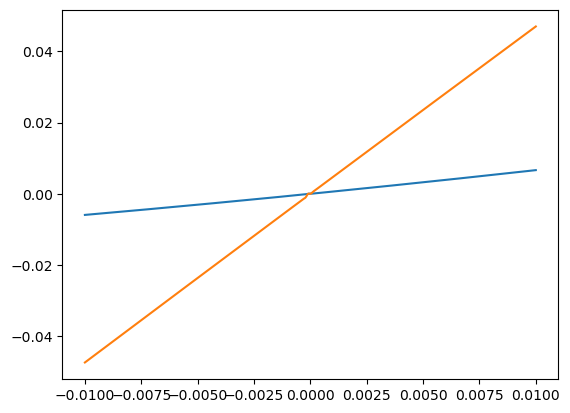

In [47]:
plt.plot(np.linspace(-1e-2, 1e-2, 1000), disp_shift(np.linspace(-1e-2, 1e-2, 1000)))
plt.plot(np.linspace(-1e-2, 1e-2, 1000), disp_shift2(np.linspace(-1e-2, 1e-2, 1000)))

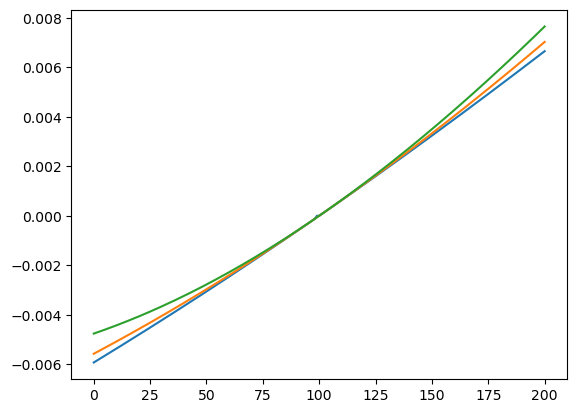

In [26]:
plt.plot([twiss.rows['qd.52110'].x[0] for i, twiss in enumerate(twisses)])
plt.plot([twiss0.rows['qd.52110'].dx[0]*delta_values[i]  + twiss0.rows['qd.52110'].ddx[0] * delta_values[i]**2 for i, twiss in enumerate(twisses)])
plt.plot([twiss.rows['qd.52110'].dx[0]*delta_values[i]  + twiss.rows['qd.52110'].ddx[0] * delta_values[i]**2 for i, twiss in enumerate(twisses)])

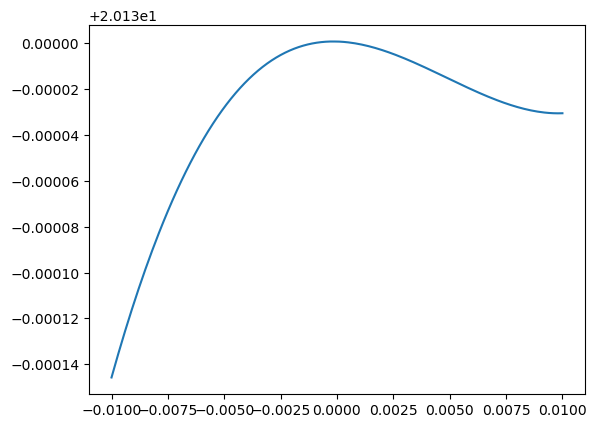

In [27]:
plt.plot(delta_values, [twiss.qx for twiss in twisses])

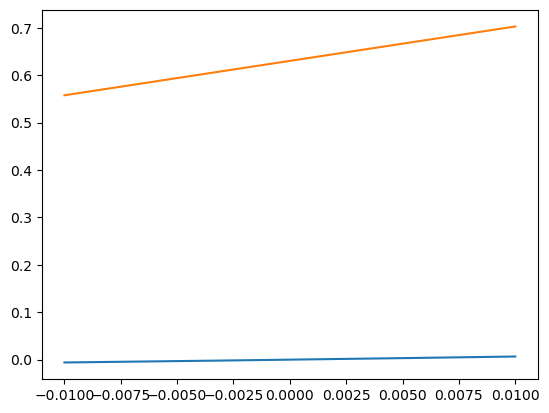

In [28]:
plt.plot(np.linspace(-1e-2, 1e-2, 1000), disp_shift(np.linspace(-1e-2, 1e-2, 1000)))
plt.plot(np.linspace(-1e-2, 1e-2, 1000), dx_shift(np.linspace(-1e-2, 1e-2, 1000)))

NameError: name 'mon_truc2' is not defined

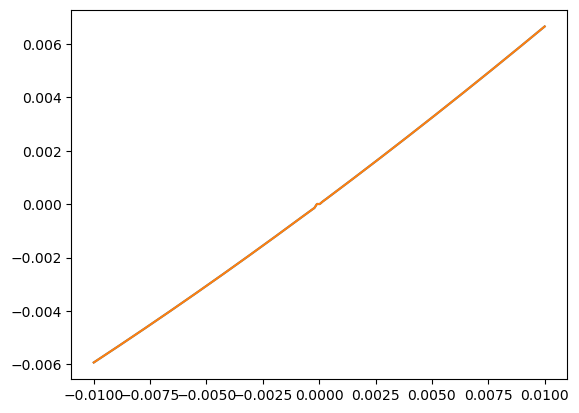

In [29]:
plt.plot(np.linspace(-1e-2, 1e-2, 1000),  disp_shift(np.linspace(-1e-2, 1e-2, 1000)))
# plt.plot(np.linspace(-1e-2, 1e-2, 1000), np.linspace(-1e-2, 1e-2, 1000) * dx_shift(np.linspace(-1e-2, 1e-2, 1000)))
plt.plot(np.linspace(-1e-2, 1e-2, 1000), mon_truc(np.linspace(-1e-2, 1e-2, 1000)))
plt.plot(np.linspace(-1e-2, 1e-2, 1000), mon_truc2(np.linspace(-1e-2, 1e-2, 1000)))

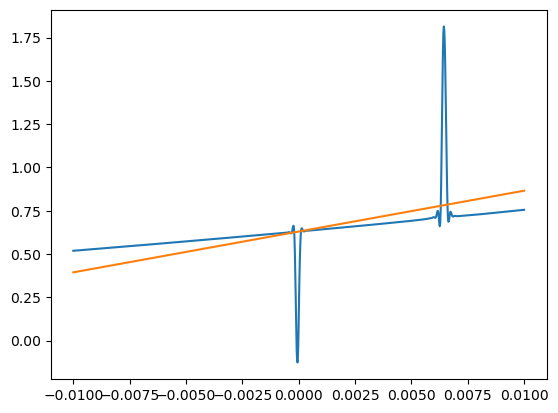

In [ ]:
plt.plot(np.linspace(-1e-2, 1e-2, 1000), disp_shift(np.linspace(-1e-2, 1e-2, 1000))/np.linspace(-1e-2, 1e-2, 1000))
plt.plot(np.linspace(-1e-2, 1e-2, 1000), dx_shift(np.linspace(-1e-2, 1e-2, 1000)))

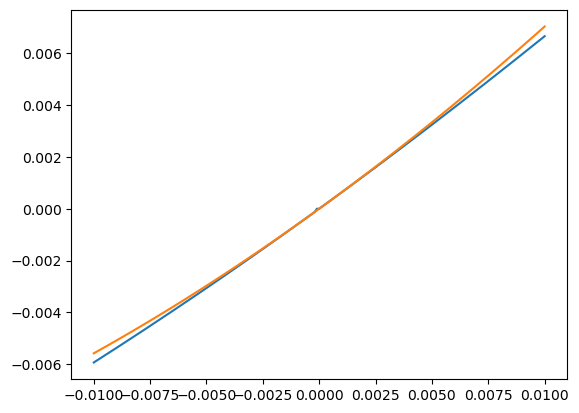

In [ ]:
plt.plot(delta_values, x )
plt.plot(delta_values, delta_values * ([twiss0.rows['qd.52110'].dx[0]  + twiss0.rows['qd.52110'].ddx[0] * delta_values[i] for i, twiss in enumerate(twisses)]))

In [ ]:
nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224
num_part = 1_000_000
import xpart as xp
line = xt.load('../../injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                          nemitt_y=nemitt_y,
                                          sigma_z=sigma_z, num_particles=num_particles, line=line)

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
*** Maximum RMS bunch length 0.2333663781336932m.
... distance to target bunch length: -2.2228e-01
... distance to target bunch length: 4.5424e-03
... distance to target bunch length: 4.3382e-03
... distance to target bunch length: -6.6565e-03
... distance to target bunch length: 2.0203e-03
... distance to target bunch length: -5.7185e-04
... distance to target bunch length: 1.0779e-04
... distance to target bunch length: 4.7891e-06
... distance to target bunch length: -2.0504e-09
... distance to target bunch length: 9.6490e-08
--> Bunch length: 0.22399999794961267
--> Emittance: 0.3434772146538057


In [ ]:
np.min(part.delta), np.max(part.delta)

(LinkedArrayCpu(-0.00363602), LinkedArrayCpu(0.00362414))

In [ ]:
dpp_bunch = np.std(part.delta)

# plot resonance opt

In [3]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
Qp = 20.13/2
alpha = np.linspace(0.5, 2.5, 1000)
ax.plot(np.zeros(1000), np.ones(1000) * -0.13/Qp, label=f'Qx=0')
ax.plot(alpha, -0.18/alpha/Qp, label='Qy=0')
ax.plot(alpha, 0.1533/alpha/Qp, label='Qy=1/3')
ax.plot(alpha, 0.05/(1-alpha)/Qp, label='Qx=Qy')
ax.plot(alpha, -0.08/(2-alpha)/Qp, label='2Qx=Qy')
ax.plot(alpha, (0.1533/alpha/Qp -0.08/(2-alpha)/Qp)/2, label='(Qy=1/3 + 2Qx=Qy)/2')
ax.set_ylim(-1.5e-2,1.5e-2)
ax.vlines(1.3143, -1.5e-2, 1.5e-2, ls='--', color='k', label='alpha=1.3143')
ax.legend()

In [ ]:
ax.plot(alpha, (0.1533/alpha/Qp -0.08/(2-alpha)/Qp)/2)

: 

# Precise plot presentation

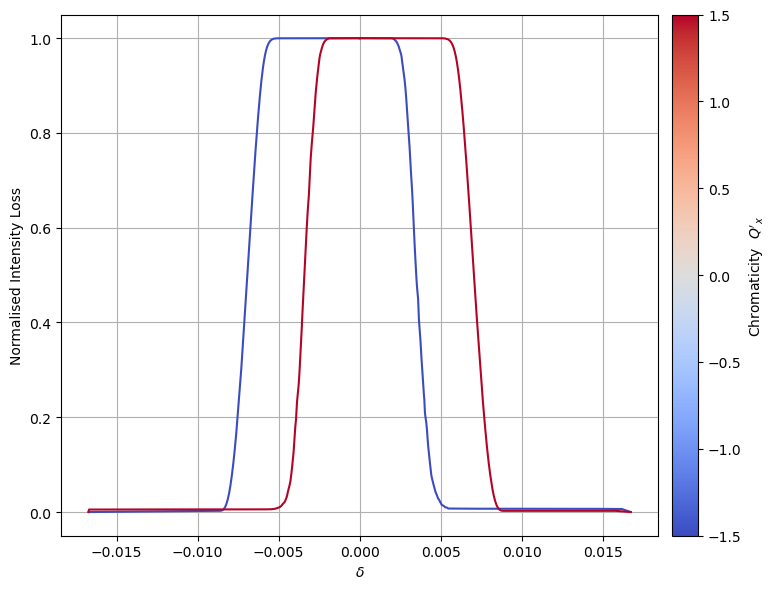

In [64]:
fig, ax = plot_intensity_drop(normalised_intensity, line_types=['linear'], chromas = [-1.5, 1.5], planes = ['DPpos', 'DPneg'], deltaq=False, symmetrize=False, cmap=colormaps['coolwarm'])